<a href="https://colab.research.google.com/github/dj2802/dhanush-codeboosters-2026/blob/main/Day_02_Database_SQL_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2: Database Fundamentals + SQL + Data Visualization
## Codeboosters Tech — Data Engineering + GenAI Internship Program

---

**Continuity:** We continue with the same `student_performance.csv` dataset from Day 1.  
Today we store it in a **real database**, query it with **SQL**, and visualize results with **Matplotlib**.

**Pipeline Today:**
```
student_performance.csv  →  SQLite Database  →  SQL Queries  →  DataFrames  →  Charts
```

---

## What You Will Learn
1. What a database is and how it is structured
2. How to create a SQLite database from a CSV file
3. SQL: SELECT, WHERE, ORDER BY, LIMIT, DISTINCT, GROUP BY, HAVING, JOINs
4. How to create Bar, Histogram, Line, and Pie charts using Matplotlib
5. How to connect SQL query results directly to charts

---

## UNIT 1: Database Fundamentals

### What is a Database?

**Level 1 — Simple:** A database is an organized place to store data so it can be found and retrieved quickly.

**Level 2 — Analogy:** Think of your college library. Every book has a location number (Primary Key), a title, author, and subject. The librarian finds any book in seconds because the system is organized. A database is a digital library — but for data.

**Level 3 — Technical:** A database is a structured collection of data managed by a DBMS (Database Management System). It provides persistent storage, ACID compliance, concurrent access, and a query language (SQL).

### Why SQLite?
- Built into Python — no installation needed
- Entire database stored in one file (college.db)
- Perfect for learning and small projects
- Same SQL syntax as MySQL, PostgreSQL

---

## SETUP: Import Libraries

Before anything else, we import all the tools we need for today.

In [ ]:
# ============================================================
# CELL 1: Import all required libraries
# ============================================================

import sqlite3
# sqlite3 is Python's built-in database library
# It allows Python to create, connect to, and query SQLite databases
# No pip install needed — sqlite3 comes with Python automatically

import pandas as pd
# pandas: our Day 1 tool for DataFrames
# Today we also use it to load data INTO the database (to_sql)
# and to read query results OUT of the database (read_sql_query)

import matplotlib.pyplot as plt
# matplotlib.pyplot is the plotting sub-module of matplotlib
# 'plt' is the standard alias — used by everyone in the industry
# We use it to create bar charts, histograms, line charts, pie charts

import warnings
warnings.filterwarnings('ignore')
# Suppresses non-critical warning messages that clutter output

print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All libraries imported successfully!
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Expected Output:**
```
All libraries imported successfully!
pandas version: 1.x.x
sqlite3 version: 2.6.0
```

---

## STEP 1: Load the CSV Dataset (from Day 1)

Upload `student_performance.csv` to Colab Files panel, then run the cell below.

In [ ]:
# ============================================================
# CELL 2: Load the student dataset (continuation from Day 1)
# ============================================================

df = pd.read_csv('student_performance.csv')
# Same CSV from Day 1 — we load it into a Pandas DataFrame first
# Then we will transfer it into the SQLite database

print(f"Dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows:")
df.head(3)

Dataset loaded: 30 students, 13 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


---
## STEP 2: Create the SQLite Database

We now create a real database file and load the student data into it.

**Key Concepts:**
- `sqlite3.connect()` creates or opens a database file
- `conn` is the connection object — our link to the database
- `cursor` is the tool that executes SQL commands
- `df.to_sql()` writes the DataFrame as a database table

In [ ]:
# ============================================================
# CELL 3: Create SQLite database and load student data
# ============================================================

# Step A: Connect to (or create) a database file
conn = sqlite3.connect('college.db')
# 'conn' = our connection to the database
# 'college.db' = the file that will be created in Colab's filesystem
# If 'college.db' already exists, it just opens it
# If it doesn't exist, SQLite creates it automatically

# Step B: Create a cursor — the SQL execution tool
cursor = conn.cursor()
# cursor is like a 'pen' that writes SQL commands into the database
# Every SQL query goes through the cursor

# Step C: Write the DataFrame to the database as a table
df.to_sql(
    'students',      # Name of the table to create in the database
    conn,            # Which database connection to use
    if_exists='replace',  # If 'students' table exists, replace it
    index=False      # Do NOT write DataFrame row numbers as a column
)
# to_sql() automatically:
#   1. Creates the table with correct column names and types
#   2. Inserts all 30 rows from the DataFrame
# Without to_sql(), we would need to write 30 INSERT statements!

# Step D: Verify the table was created
cursor.execute("SELECT COUNT(*) FROM students")
# cursor.execute() runs a SQL command
# SELECT COUNT(*) counts all rows in the students table

count = cursor.fetchone()[0]
# .fetchone() retrieves the first result row
# [0] gets the first value from that row (our count)

print(f"Database 'college.db' created successfully!")
print(f"Table 'students' has {count} rows")

Database 'college.db' created successfully!
Table 'students' has 30 rows


In [ ]:
# ============================================================
# CELL 4: Inspect the table structure
# ============================================================

# PRAGMA is a special SQLite command (not standard SQL)
# table_info() shows the structure of a table
cursor.execute("PRAGMA table_info(students)")
columns_info = cursor.fetchall()
# .fetchall() retrieves ALL result rows (not just one)

print("Table structure of 'students':")
print(f"{'Column Name':<25} {'Data Type':<12}")
print("-" * 38)
for col in columns_info:
    # col is a tuple: (id, name, type, notnull, default, pk)
    print(f"{col[1]:<25} {col[2]:<12}")
    # col[1] = column name, col[2] = data type
    # :<25 means left-align in 25 characters (for neat formatting)

Table structure of 'students':
Column Name               Data Type   
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


---
## UNIT 2: SQL Queries

### The Standard SQL Query Pattern

```sql
SELECT  column1, column2        -- Which columns to show
FROM    table_name              -- Which table to read from
WHERE   condition               -- Filter rows (optional)
GROUP BY column                 -- Group rows (optional)
HAVING  group_condition         -- Filter groups (optional)
ORDER BY column DESC            -- Sort results (optional)
LIMIT   10;                     -- Max rows to return (optional)
```

**Helper function:** We create a reusable function to run SQL queries cleanly.

---

In [ ]:
# ============================================================
# CELL 5: Helper function to run SQL queries
# ============================================================

def run_query(sql, description=""):
    """
    Runs a SQL query and returns results as a Pandas DataFrame.

    Parameters:
    -----------
    sql         : str  - The SQL query string to execute
    description : str  - A label to print above the results

    Returns:
    --------
    Pandas DataFrame containing the query results
    """
    if description:
        print(f"\n{'='*55}")
        print(f"  {description}")
        print(f"{'='*55}")

    result = pd.read_sql_query(sql, conn)
    # pd.read_sql_query() does two things:
    #   1. Executes the SQL query against our database (conn)
    #   2. Converts the results into a Pandas DataFrame
    # This is the KEY function connecting SQL + Pandas

    print(result.to_string(index=False))
    # .to_string(index=False) prints the DataFrame without row numbers

    return result
    # We return the DataFrame so we can use it for charting later

print("Helper function 'run_query' defined successfully!")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully!
Usage: run_query(sql_string, description_label)


---
### SQL Query 1: View All Students (Basic SELECT)

The most basic SQL command — retrieve data from a table.

In [ ]:
# ============================================================
# CELL 6: SQL Query 1 — Basic SELECT
# ============================================================

query1 = """
    SELECT student_id, name, department, math_score, attendance_percentage
    FROM students
    LIMIT 10
"""
# SELECT       : keyword that starts every data retrieval query
# student_id, name, department, ... : columns we want to see
# FROM students : which table to read from
# LIMIT 10     : return only the first 10 rows
#                Without LIMIT, all 30 rows would appear
# Triple quotes """...""" let us write multi-line strings in Python

result1 = run_query(query1, "Query 1: First 10 Students (SELECT + LIMIT)")

# Comparison with Pandas equivalent from Day 1:
# SQL:    SELECT name, department FROM students LIMIT 10
# Pandas: df[['name','department']].head(10)


  Query 1: First 10 Students (SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


---
### SQL Query 2: Find Top 5 Math Scorers (ORDER BY + LIMIT)

Sort the results and take the top few rows.

In [ ]:
# ============================================================
# CELL 7: SQL Query 2 — ORDER BY + LIMIT
# ============================================================

query2 = """
    SELECT name, department, math_score
    FROM students
    ORDER BY math_score DESC
    LIMIT 5
"""
# ORDER BY math_score : sort by the math_score column
# DESC                : descending order (highest first)
#                       ASC would be ascending (lowest first)
# LIMIT 5             : show only the top 5 results
#
# Pandas equivalent: df.sort_values('math_score', ascending=False).head(5)

result2 = run_query(query2, "Query 2: Top 5 Math Scorers (ORDER BY DESC + LIMIT)")


  Query 2: Top 5 Math Scorers (ORDER BY DESC + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


---
### SQL Query 3: Filter by Department (WHERE clause)

In [ ]:
# ============================================================
# CELL 8: SQL Query 3 — WHERE filter
# ============================================================

query3 = """
    SELECT name, math_score, science_score, programming_score, attendance_percentage
    FROM students
    WHERE department = 'Computer Science'
    ORDER BY programming_score DESC
"""
# WHERE department = 'Computer Science'
#   Filters rows — only returns rows where department equals 'Computer Science'
#   String values in SQL use SINGLE quotes, not double quotes
#   SQL is case-sensitive for string values: 'computer science' would return 0 rows!
#
# Pandas equivalent: df[df['department'] == 'Computer Science']

result3 = run_query(query3, "Query 3: Computer Science Students (WHERE filter)")
print(f"\nTotal CS students found: {len(result3)}")


  Query 3: Computer Science Students (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor         

In [ ]:
# ============================================================
# CELL 9: SQL Query 4 — Multiple WHERE conditions
# ============================================================

query4 = """
    SELECT name, department, attendance_percentage
    FROM students
    WHERE attendance_percentage > 90
    AND department != 'Civil'
    ORDER BY attendance_percentage DESC
"""
# WHERE attendance_percentage > 90  : first condition
# AND department != 'Civil'         : second condition (must ALSO be true)
#   AND  = both conditions must be true
#   OR   = at least one condition must be true
#   !=   = 'not equal to' (some databases use <>)
#
# Pandas equivalent:
# df[(df['attendance_percentage'] > 90) & (df['department'] != 'Civil')]

result4 = run_query(query4, "Query 4: High Attendance (>90%) Excluding Civil Dept")


  Query 4: High Attendance (>90%) Excluding Civil Dept
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


---
### SQL Query 5: Average Score per Department (GROUP BY + AVG)

**GROUP BY** is one of the most powerful SQL concepts for Data Engineers.

In [ ]:
# ============================================================
# CELL 10: SQL Query 5 — GROUP BY with aggregate functions
# ============================================================

query5 = """
    SELECT
        department,
        COUNT(*)                              AS num_students,
        ROUND(AVG(math_score), 2)             AS avg_math,
        ROUND(AVG(science_score), 2)          AS avg_science,
        ROUND(AVG(programming_score), 2)      AS avg_programming,
        ROUND(AVG(attendance_percentage), 2)  AS avg_attendance
    FROM students
    GROUP BY department
    ORDER BY avg_math DESC
"""
# SELECT department : the column we are grouping by
# COUNT(*)          : count of rows in each group
# AVG(math_score)   : average math score for each group
# ROUND(..., 2)     : round to 2 decimal places
# AS num_students   : 'AS' creates an alias (a readable column name)
# GROUP BY department:
#   Separates students into 4 groups: CS, Electronics, Mechanical, Civil
#   Then calculates COUNT and AVG separately for each group
#
# Pandas equivalent: df.groupby('department').agg({'math_score':'mean', ...})

result5 = run_query(query5, "Query 5: Department-wise Average Scores (GROUP BY)")


  Query 5: Department-wise Average Scores (GROUP BY)
      department  num_students  avg_math  avg_science  avg_programming  avg_attendance
Computer Science            13     85.62        84.46            89.23           90.69
      Mechanical             6     71.00        76.50            49.33           83.50
     Electronics             6     71.00        74.17            61.50           80.33
           Civil             5     63.40        66.60            40.60           74.60


In [ ]:
# ============================================================
# CELL 11: SQL Query 6 — HAVING (filter on groups)
# ============================================================

query6 = """
    SELECT
        department,
        ROUND(AVG(math_score), 2) AS avg_math,
        COUNT(*) AS students
    FROM students
    GROUP BY department
    HAVING AVG(math_score) > 70
    ORDER BY avg_math DESC
"""
# HAVING AVG(math_score) > 70 :
#   Filters GROUPS (not rows) after GROUP BY
#   Only shows departments where the average math score is above 70
#
# KEY DIFFERENCE:
#   WHERE  = filters individual ROWS   (applied BEFORE grouping)
#   HAVING = filters GROUPS            (applied AFTER grouping)
#
# SQL execution order: FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY

result6 = run_query(query6, "Query 6: Departments with Avg Math > 70 (HAVING)")


  Query 6: Departments with Avg Math > 70 (HAVING)
      department  avg_math  students
Computer Science     85.62        13
      Mechanical     71.00         6
     Electronics     71.00         6


In [ ]:
# ============================================================
# CELL 12: SQL Query 7 — Gender-wise analysis
# ============================================================

query7 = """
    SELECT
        gender,
        COUNT(*) AS num_students,
        ROUND(AVG(math_score), 2)             AS avg_math,
        ROUND(AVG(programming_score), 2)      AS avg_programming,
        ROUND(AVG(attendance_percentage), 2)  AS avg_attendance
    FROM students
    GROUP BY gender
"""
# Groups students by gender and calculates statistics for each group
# This is useful for equity analysis in educational data

result7 = run_query(query7, "Query 7: Gender-wise Performance Analysis")


  Query 7: Gender-wise Performance Analysis
gender  num_students  avg_math  avg_programming  avg_attendance
Female            15     78.47             70.2           88.53
  Male            15     73.67             65.0           80.47


In [ ]:
# ============================================================
# CELL 13: SQL Query 8 — Total Score ranking with calculated column
# ============================================================

query8 = """
    SELECT
        name,
        department,
        math_score + science_score + english_score + programming_score AS total_score,
        attendance_percentage
    FROM students
    ORDER BY total_score DESC
    LIMIT 10
"""
# math_score + science_score + english_score + programming_score AS total_score :
#   We create a NEW calculated column inside the SQL query
#   SQL performs the addition row by row automatically
#   AS total_score gives this calculated column a name
#   This is the SQL equivalent of df['total_score'] = df['math'] + df['science'] + ...
#   from Day 1!

result8 = run_query(query8, "Query 8: Top 10 Students by Total Score")


  Query 8: Top 10 Students by Total Score
          name       department  total_score  attendance_percentage
    Ananya Das Computer Science          371                     98
   Tanvi Mehta Computer Science          367                     97
Akanksha Yadav Computer Science          365                     95
    Arjun Nair Computer Science          356                     90
   Divya Singh Computer Science          356                     96
Swati Kulkarni Computer Science          354                     94
     Amit Bose Computer Science          336                     91
    Suresh Rao Computer Science          334                     88
  Nisha Kapoor Computer Science          327                     89
  Aarav Sharma Computer Science          326                     92


---
### SQL JOINs — Combining Two Tables

To demonstrate JOINs, we create a second table: `departments`.

In [ ]:
# ============================================================
# CELL 14: Create a departments table for JOIN demonstration
# ============================================================

# Create a departments reference table
dept_data = {
    'dept_code':   ['CS', 'EC', 'ME', 'CE'],
    'dept_name':   ['Computer Science', 'Electronics', 'Mechanical', 'Civil'],
    'hod_name':    ['Dr. Sharma', 'Dr. Reddy', 'Dr. Patel', 'Dr. Kumar'],
    'established': [1985, 1988, 1972, 1965],
    'intake':      [60, 60, 60, 60]
}
# We define a Python dictionary: keys = column names, values = lists of data

dept_df = pd.DataFrame(dept_data)
# pd.DataFrame() converts a dictionary into a DataFrame
# Each key becomes a column, each list becomes that column's values

# Write departments table to the database
dept_df.to_sql('departments', conn, if_exists='replace', index=False)

print("Created 'departments' table:")
print(dept_df.to_string(index=False))

# Now add dept_code to the students table so we can JOIN
# (Map department names to codes)
dept_map = {
    'Computer Science': 'CS',
    'Electronics':      'EC',
    'Mechanical':       'ME',
    'Civil':            'CE'
}
# Dictionary mapping full name → code

df['dept_code'] = df['department'].map(dept_map)
# .map() replaces each value using the dictionary
# 'Computer Science' → 'CS', 'Electronics' → 'EC', etc.

df.to_sql('students', conn, if_exists='replace', index=False)
# Reload the students table with the new dept_code column

print("\nUpdated students table with dept_code column")

Created 'departments' table:
dept_code        dept_name   hod_name  established  intake
       CS Computer Science Dr. Sharma         1985      60
       EC      Electronics  Dr. Reddy         1988      60
       ME       Mechanical  Dr. Patel         1972      60
       CE            Civil  Dr. Kumar         1965      60

Updated students table with dept_code column


In [ ]:
# ============================================================
# CELL 15: INNER JOIN — combine students with departments
# ============================================================

query_join = """
    SELECT
        s.name,
        s.math_score,
        d.dept_name,
        d.hod_name,
        d.established
    FROM students AS s
    INNER JOIN departments AS d
        ON s.dept_code = d.dept_code
    ORDER BY s.math_score DESC
    LIMIT 8
"""
# FROM students AS s    : 'students' table, aliased as 's'
# INNER JOIN departments AS d : join with 'departments' table, aliased as 'd'
# ON s.dept_code = d.dept_code :
#   This is the JOIN CONDITION — the matching column in both tables
#   A row from students is combined with a row from departments
#   only when their dept_code values MATCH
# s.name, d.hod_name :
#   We use 's.' and 'd.' prefixes to specify which table each column comes from
#   Required when both tables have columns with the same name
#
# INNER JOIN returns only rows that have a MATCH in BOTH tables
# If a student had an unknown dept_code, they would be EXCLUDED

result_join = run_query(query_join, "JOIN: Students with Department Details (INNER JOIN)")


  JOIN: Students with Department Details (INNER JOIN)
          name  math_score        dept_name   hod_name  established
    Ananya Das          95 Computer Science Dr. Sharma         1985
   Tanvi Mehta          93 Computer Science Dr. Sharma         1985
    Arjun Nair          92 Computer Science Dr. Sharma         1985
Akanksha Yadav          91 Computer Science Dr. Sharma         1985
Swati Kulkarni          90 Computer Science Dr. Sharma         1985
   Divya Singh          88 Computer Science Dr. Sharma         1985
  Ritu Agarwal          87      Electronics  Dr. Reddy         1988
     Amit Bose          86 Computer Science Dr. Sharma         1985


---
## UNIT 3: Data Visualization with Matplotlib

Now we turn our SQL results into professional charts.

**The Pattern we follow:**
```
SQL Query → pd.read_sql_query() → DataFrame → Matplotlib chart
```

**Matplotlib anatomy:**
```python
fig, ax = plt.subplots(figsize=(width, height))  # Create canvas
ax.bar(x, y)                                     # Draw the chart
ax.set_title('...')                               # Add title
ax.set_xlabel('...')                              # Label x-axis
ax.set_ylabel('...')                              # Label y-axis
plt.tight_layout()                               # Fix label clipping
plt.show()                                       # Display chart
```

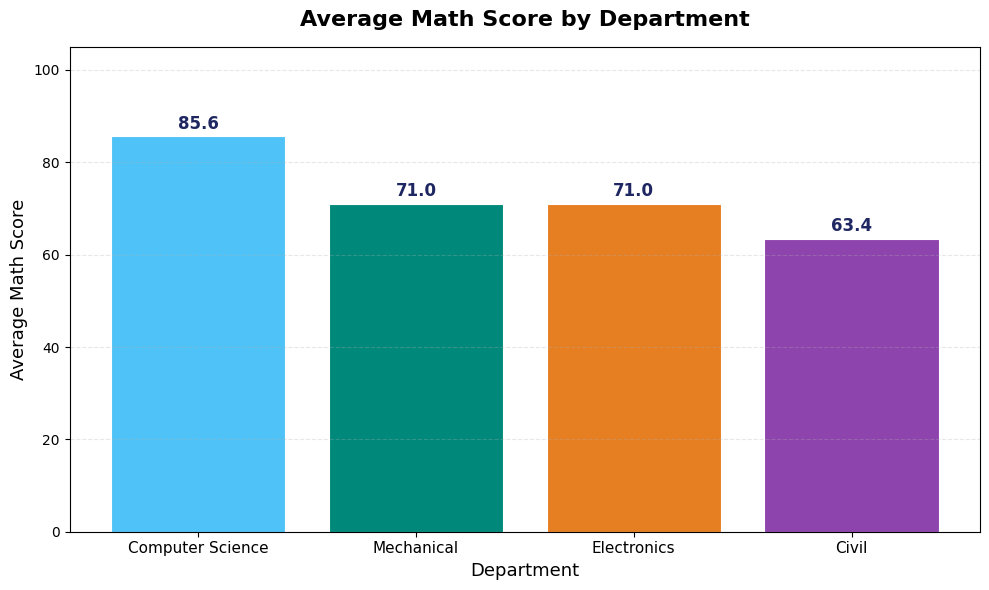

In [ ]:
# ============================================================
# CELL 16: Chart 1 — Bar Chart: Average Math Score by Department
# ============================================================

# Step 1: Get data using SQL
chart1_sql = """
    SELECT department, ROUND(AVG(math_score), 2) AS avg_math
    FROM students
    GROUP BY department
    ORDER BY avg_math DESC
"""
chart1_data = pd.read_sql_query(chart1_sql, conn)
# pd.read_sql_query runs the SQL and returns a DataFrame
# chart1_data has two columns: 'department' and 'avg_math'

# Step 2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
# fig = the whole figure (canvas)
# ax  = the axes object (the actual plot area)
# figsize=(10, 6) = 10 inches wide, 6 inches tall

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']
# List of hex color codes — one color per department bar
# Same color palette as our PPT slides for consistency

bars = ax.bar(
    chart1_data['department'],  # x-axis values (category labels)
    chart1_data['avg_math'],    # y-axis values (heights of bars)
    color=bar_colors,           # colors for each bar
    edgecolor='white',          # white border around each bar
    linewidth=0.8               # thickness of the border
)
# ax.bar() draws one bar per x-value, with height = y-value

# Add value labels ON TOP of each bar
for bar in bars:
    # Loop through each bar object
    height = bar.get_height()
    # .get_height() returns the bar's height (= the avg_math value)
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        height + 0.8,                        # y position: just above bar top
        f'{height:.1f}',                     # text: height formatted to 1 decimal
        ha='center', va='bottom',            # horizontal/vertical alignment
        fontsize=12, fontweight='bold',
        color='#1E2761'
    )

ax.set_title('Average Math Score by Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)
ax.set_ylim(0, 105)  # y-axis from 0 to 105 so labels above bars fit
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
# axis='y' adds horizontal gridlines only
# alpha=0.3 makes gridlines 70% transparent
# linestyle='--' makes them dashed

plt.tight_layout()  # Adjusts spacing to prevent label clipping
plt.show()          # Displays the chart

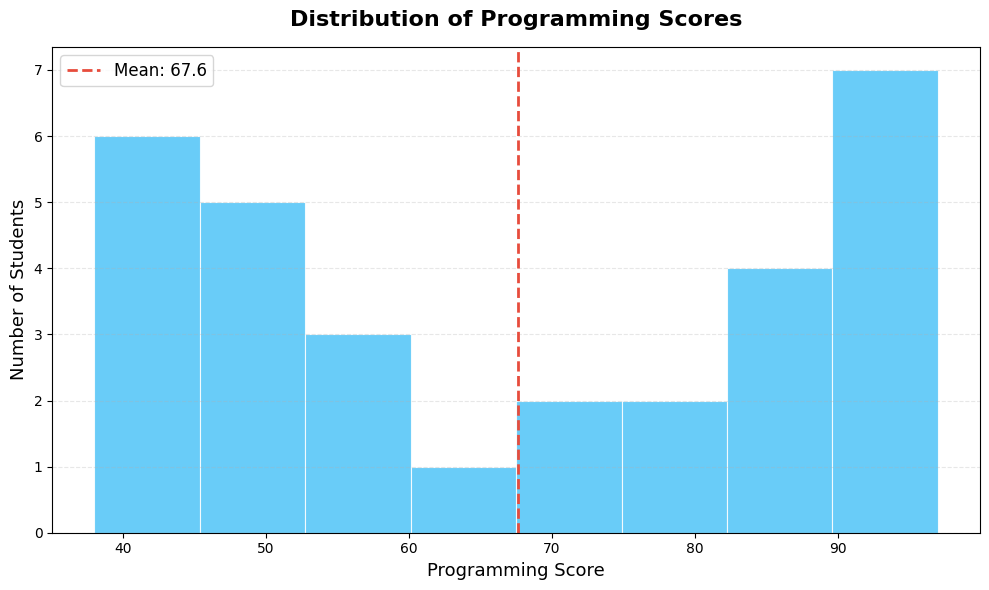

In [ ]:
# ============================================================
# CELL 17: Chart 2 — Histogram: Distribution of Programming Scores
# ============================================================

# Get programming scores as a list
prog_scores = df['programming_score'].tolist()
# .tolist() converts a Pandas Series to a regular Python list
# Matplotlib's hist() works with both — tolist() is just explicit

fig, ax = plt.subplots(figsize=(10, 6))

n, bins, patches = ax.hist(
    prog_scores,        # The data to visualize
    bins=8,             # Divide score range into 8 equal intervals
    color='#4FC3F7',    # Bar fill color
    edgecolor='white',  # White border between bars
    linewidth=0.8,
    alpha=0.85          # Slight transparency
)
# ax.hist() returns three values:
#   n       = frequency count for each bin
#   bins    = the bin edges (breakpoints on x-axis)
#   patches = the bar objects (we can color them individually)

# Add a vertical line showing the mean score
mean_score = sum(prog_scores) / len(prog_scores)
ax.axvline(
    x=mean_score,           # x position of the vertical line
    color='#E74C3C',        # red color for visibility
    linestyle='--',         # dashed line style
    linewidth=2,
    label=f'Mean: {mean_score:.1f}'  # label for the legend
)
# axvline = 'axis vertical line' — draws a vertical reference line

ax.set_title('Distribution of Programming Scores', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Programming Score', fontsize=13)
ax.set_ylabel('Number of Students', fontsize=13)
ax.legend(fontsize=12)  # Shows the mean line label
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

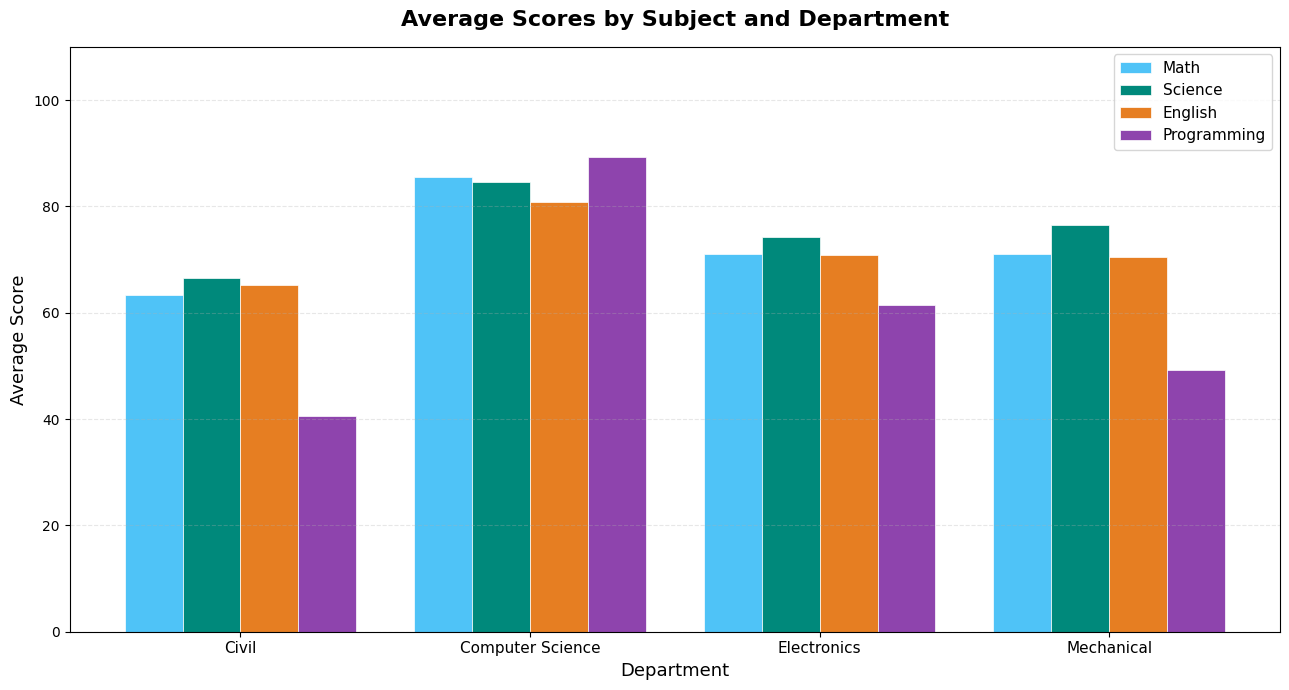

In [ ]:
# ============================================================
# CELL 18: Chart 3 — Grouped Bar Chart: All Score Types by Department
# ============================================================

import numpy as np
# numpy: Python library for numerical operations
# We use it here to position grouped bars side by side

# Get department averages for all score columns
chart3_sql = """
    SELECT
        department,
        ROUND(AVG(math_score), 1)        AS math,
        ROUND(AVG(science_score), 1)     AS science,
        ROUND(AVG(english_score), 1)     AS english,
        ROUND(AVG(programming_score), 1) AS programming
    FROM students
    GROUP BY department
    ORDER BY department
"""
chart3_data = pd.read_sql_query(chart3_sql, conn)

# Set up grouped bar positions
depts    = chart3_data['department'].tolist()
subjects = ['math', 'science', 'english', 'programming']
colors   = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']
x        = np.arange(len(depts))   # [0, 1, 2, 3] — one position per dept
width    = 0.2                     # width of each individual bar

fig, ax = plt.subplots(figsize=(13, 7))

for i, (subject, color) in enumerate(zip(subjects, colors)):
    # zip() pairs subjects and colors: ('math','#4FC3F7'), ('science','#00897B')...
    # enumerate() gives us an index i: 0, 1, 2, 3
    offset = (i - 1.5) * width  # offset positions bars: -1.5, -0.5, 0.5, 1.5
    bars = ax.bar(x + offset, chart3_data[subject], width,
                  label=subject.capitalize(), color=color,
                  edgecolor='white', linewidth=0.5)

ax.set_title('Average Scores by Subject and Department', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Score', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(depts, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

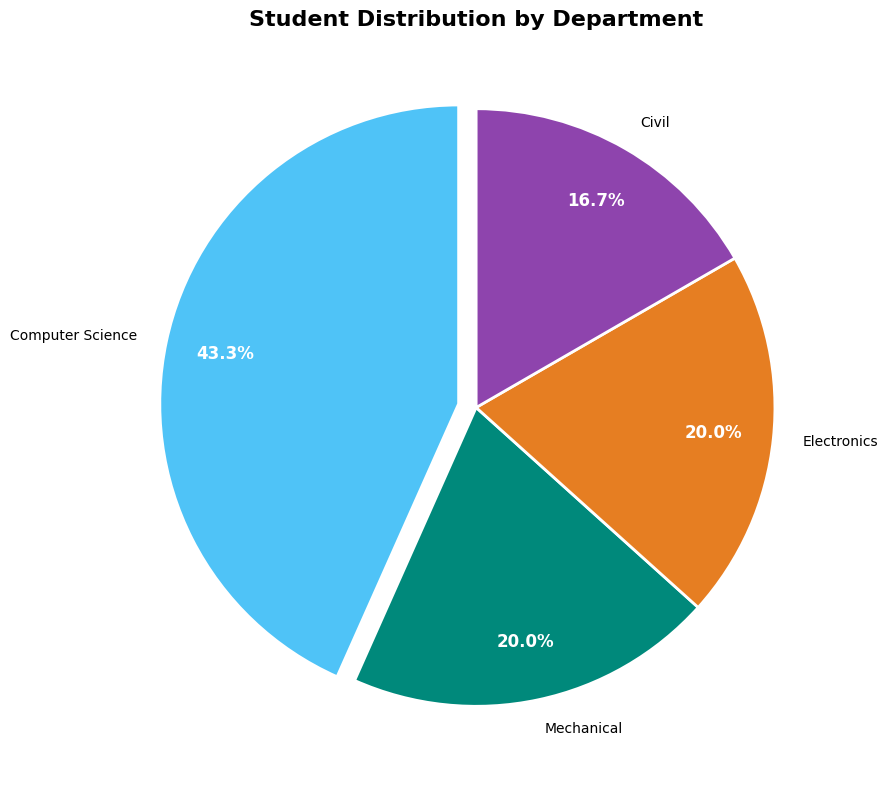


Student count per department:
      department  num_students
Computer Science            13
      Mechanical             6
     Electronics             6
           Civil             5


In [ ]:
# ============================================================
# CELL 19: Chart 4 — Pie Chart: Students per Department
# ============================================================

chart4_sql = """
    SELECT department, COUNT(*) AS num_students
    FROM students
    GROUP BY department
    ORDER BY num_students DESC
"""
chart4_data = pd.read_sql_query(chart4_sql, conn)

labels  = chart4_data['department'].tolist()
sizes   = chart4_data['num_students'].tolist()
colors  = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']
explode = [0.06, 0, 0, 0]  # Slightly separate the first (largest) slice

fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,          # Category labels around the pie
    colors=colors,          # Fill colors for each slice
    explode=explode,        # How far to offset each slice from center
    autopct='%1.1f%%',      # Show percentage on each slice (1 decimal)
    startangle=90,          # Rotate pie so first slice starts at top
    pctdistance=0.8,        # Position percentage text at 80% from center
    wedgeprops={'edgecolor':'white', 'linewidth':2}  # White borders
)
# ax.pie() returns:
#   wedges    = the slice objects
#   texts     = the label text objects
#   autotexts = the percentage text objects

# Style the percentage labels
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title('Student Distribution by Department', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nStudent count per department:")
print(chart4_data.to_string(index=False))

---
## MINI PROJECT: Student Performance Dashboard

**Goal:** Build a complete, professional dashboard using SQL + Matplotlib.

Combine 4 charts into a single figure using `plt.subplots(2, 2)` — a 2×2 grid.

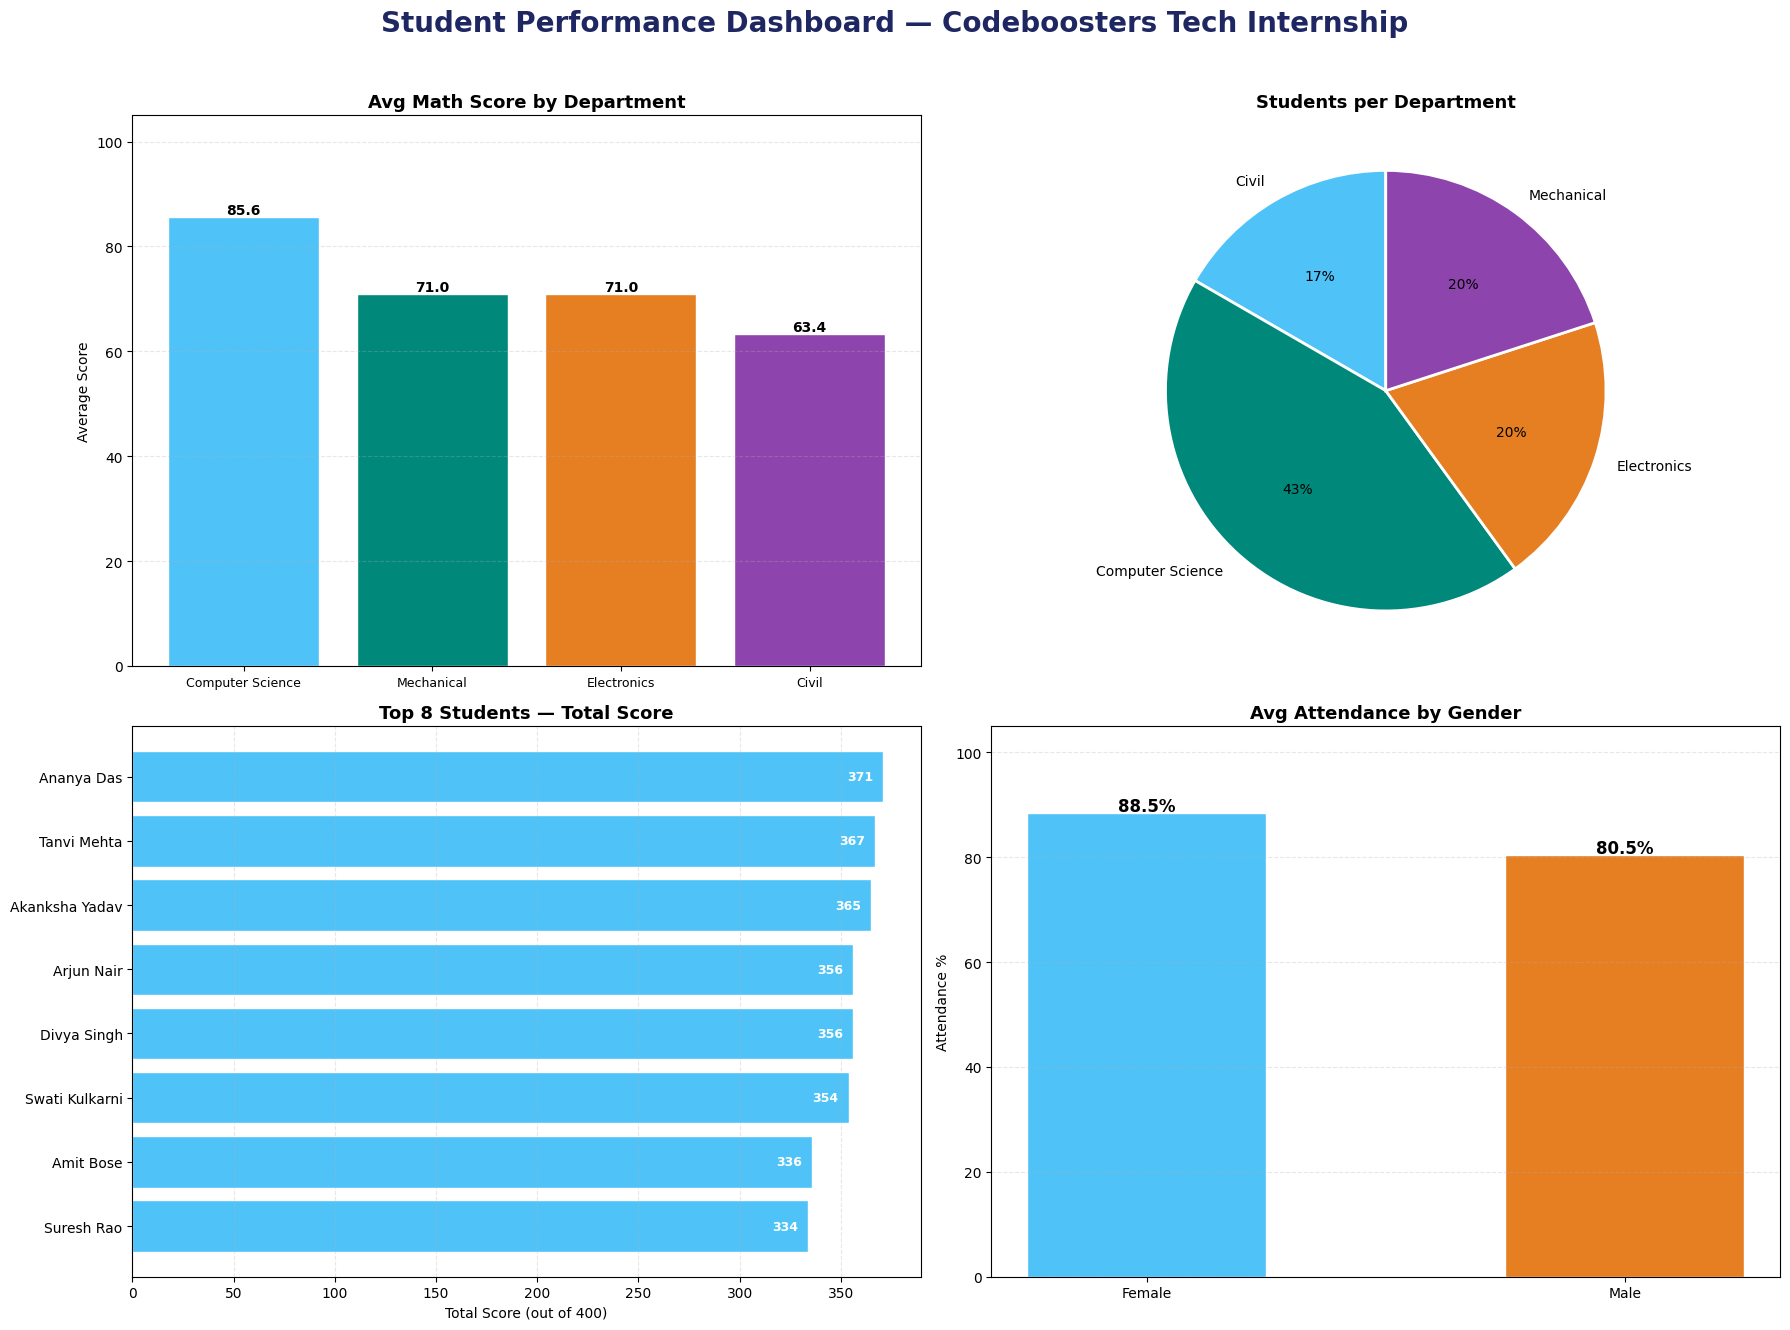


Dashboard saved as: student_dashboard.png
Upload both this notebook AND student_dashboard.png to GitHub


In [ ]:
# ============================================================
# CELL 20: MINI PROJECT — Student Performance Dashboard
# 4-panel figure with SQL-powered charts
# ============================================================

# --- Gather all data using SQL queries ---

# Panel 1 data: avg math by department
p1 = pd.read_sql_query("""
    SELECT department, ROUND(AVG(math_score),1) AS avg_math
    FROM students GROUP BY department ORDER BY avg_math DESC
""", conn)

# Panel 2 data: student count by department
p2 = pd.read_sql_query("""
    SELECT department, COUNT(*) AS count
    FROM students GROUP BY department
""", conn)

# Panel 3 data: top 8 students by total score
p3 = pd.read_sql_query("""
    SELECT name,
           math_score + science_score + english_score + programming_score AS total
    FROM students ORDER BY total DESC LIMIT 8
""", conn)

# Panel 4 data: gender-wise average attendance
p4 = pd.read_sql_query("""
    SELECT gender, ROUND(AVG(attendance_percentage),1) AS avg_att
    FROM students GROUP BY gender
""", conn)

# --- Build the Dashboard ---

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
# plt.subplots(2, 2) creates a 2-row × 2-column grid of subplots
# figsize=(18, 13) = large canvas so all 4 panels are readable
# axes is a 2D array: axes[0][0], axes[0][1], axes[1][0], axes[1][1]

fig.suptitle('Student Performance Dashboard — Codeboosters Tech Internship',
             fontsize=20, fontweight='bold', color='#1E2761', y=1.02)
# suptitle = 'super title' — main title above all subplots

colors4 = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']

# ── Panel 1 (top-left): Avg Math by Department ──
ax1 = axes[0][0]
bars1 = ax1.bar(p1['department'], p1['avg_math'], color=colors4, edgecolor='white')
for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height()}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Avg Math Score by Department', fontsize=13, fontweight='bold')
ax1.set_ylabel('Average Score'); ax1.set_ylim(0, 105)
ax1.tick_params(axis='x', labelsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ── Panel 2 (top-right): Student Count Pie ──
ax2 = axes[0][1]
ax2.pie(p2['count'], labels=p2['department'], colors=colors4,
        autopct='%1.0f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax2.set_title('Students per Department', fontsize=13, fontweight='bold')

# ── Panel 3 (bottom-left): Top 8 Students Horizontal Bar ──
ax3 = axes[1][0]
bars3 = ax3.barh(p3['name'], p3['total'], color='#4FC3F7', edgecolor='white')
# barh = horizontal bar chart
# x and y are swapped: names on y-axis, scores on x-axis
for bar in bars3:
    ax3.text(bar.get_width()-5, bar.get_y()+bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', ha='right',
             fontsize=9, color='white', fontweight='bold')
ax3.set_title('Top 8 Students — Total Score', fontsize=13, fontweight='bold')
ax3.set_xlabel('Total Score (out of 400)')
ax3.invert_yaxis()  # Highest scorer at the top
ax3.grid(axis='x', alpha=0.3, linestyle='--')

# ── Panel 4 (bottom-right): Gender Avg Attendance Bar ──
ax4 = axes[1][1]
gcolors = ['#4FC3F7', '#E67E22']
bars4 = ax4.bar(p4['gender'], p4['avg_att'], color=gcolors, edgecolor='white', width=0.5)
for bar in bars4:
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{bar.get_height()}%', ha='center', fontsize=12, fontweight='bold')
ax4.set_title('Avg Attendance by Gender', fontsize=13, fontweight='bold')
ax4.set_ylabel('Attendance %'); ax4.set_ylim(0, 105)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('student_dashboard.png', dpi=150, bbox_inches='tight')
# .savefig() saves the chart as an image file
# dpi=150 = 150 dots-per-inch resolution (good quality)
# bbox_inches='tight' prevents title/labels from being clipped
plt.show()

print("\nDashboard saved as: student_dashboard.png")
print("Upload both this notebook AND student_dashboard.png to GitHub")

In [ ]:
# ============================================================
# CELL 21: Print a comprehensive text summary report using SQL
# ============================================================

print("=" * 65)
print("     STUDENT PERFORMANCE REPORT — CODEBOOSTERS INTERNSHIP")
print("=" * 65)

# Total students
total = cursor.execute("SELECT COUNT(*) FROM students").fetchone()[0]
print(f"\nTotal Students: {total}")

# Overall averages
avgs = pd.read_sql_query("""
    SELECT ROUND(AVG(math_score),2) AS avg_math,
           ROUND(AVG(science_score),2) AS avg_sci,
           ROUND(AVG(programming_score),2) AS avg_prog,
           ROUND(AVG(attendance_percentage),2) AS avg_att
    FROM students
""", conn)
print(f"\nOverall Averages:")
print(f"  Math:           {avgs['avg_math'][0]}")
print(f"  Science:        {avgs['avg_sci'][0]}")
print(f"  Programming:    {avgs['avg_prog'][0]}")
print(f"  Attendance:     {avgs['avg_att'][0]}%")

# Top student
top = pd.read_sql_query("""
    SELECT name, department,
           math_score+science_score+english_score+programming_score AS total
    FROM students ORDER BY total DESC LIMIT 1
""", conn)
print(f"\nTop Student:      {top['name'][0]} ({top['department'][0]}) — {top['total'][0]}/400")

# Best department
best_dept = pd.read_sql_query("""
    SELECT department, ROUND(AVG(math_score+science_score+english_score+programming_score),1) AS avg_total
    FROM students GROUP BY department ORDER BY avg_total DESC LIMIT 1
""", conn)
print(f"Best Department:  {best_dept['department'][0]} (avg total: {best_dept['avg_total'][0]})")

# Low attendance
low_att = cursor.execute("SELECT COUNT(*) FROM students WHERE attendance_percentage < 75").fetchone()[0]
print(f"\nStudents needing attention (attendance < 75%): {low_att}")

print("\n" + "=" * 65)
print("Report complete. Upload notebook to GitHub.")
print("=" * 65)

     STUDENT PERFORMANCE REPORT — CODEBOOSTERS INTERNSHIP

Total Students: 30

Overall Averages:
  Math:           76.07
  Science:        77.83
  Programming:    67.6
  Attendance:     84.5%

Top Student:      Ananya Das (Computer Science) — 371/400
Best Department:  Computer Science (avg total: 340.2)

Students needing attention (attendance < 75%): 6

Report complete. Upload notebook to GitHub.


---
## Practice Questions

**Question 1:** Write a SQL query to find the average programming score for female students only.

**Question 2:** What is the difference between WHERE and HAVING? Write one example of each using the students table.

**Question 3:** Write a SQL query to find all departments where the average attendance is above 85%.

**Question 4:** What does `pd.read_sql_query()` return? What two arguments does it require?

**Question 5:** Modify Chart 1 (bar chart) to show average PROGRAMMING scores instead of math scores.

---
## Answers

In [ ]:
# Answer 1: Average programming score for female students
ans1 = pd.read_sql_query("""
    SELECT gender, ROUND(AVG(programming_score), 2) AS avg_programming
    FROM students
    WHERE gender = 'Female'
    GROUP BY gender
""", conn)
# WHERE gender = 'Female'  → filters to only female rows BEFORE grouping
# AVG(programming_score)   → calculates average from those filtered rows
print("Answer 1:")
print(ans1.to_string(index=False))

Answer 1:
gender  avg_programming
Female             70.2


In [ ]:
# Answer 3: Departments with average attendance > 85%
ans3 = pd.read_sql_query("""
    SELECT department, ROUND(AVG(attendance_percentage), 2) AS avg_attendance
    FROM students
    GROUP BY department
    HAVING AVG(attendance_percentage) > 85
    ORDER BY avg_attendance DESC
""", conn)
# HAVING filters GROUPS (not rows)
# Only departments where group average > 85 are included
print("Answer 3: Departments with avg attendance > 85%")
print(ans3.to_string(index=False))

Answer 3: Departments with avg attendance > 85%
      department  avg_attendance
Computer Science           90.69


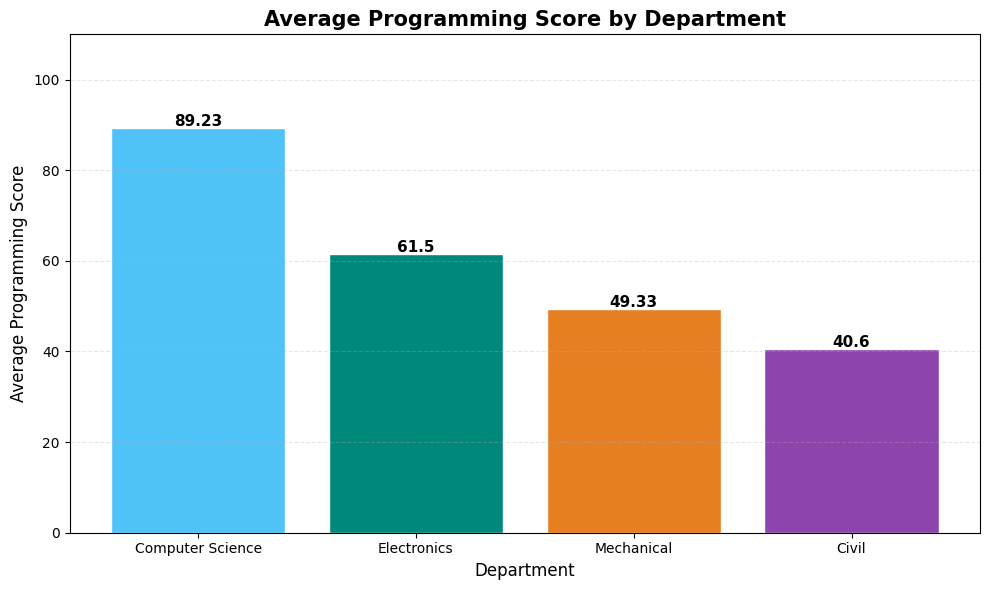

Answer 5: Chart complete


In [ ]:
# Answer 5: Bar chart — avg PROGRAMMING score by department
ans5_data = pd.read_sql_query("""
    SELECT department, ROUND(AVG(programming_score), 2) AS avg_programming
    FROM students
    GROUP BY department
    ORDER BY avg_programming DESC
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(ans5_data['department'], ans5_data['avg_programming'],
              color=['#4FC3F7','#00897B','#E67E22','#8E44AD'], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height()}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Average Programming Score by Department', fontsize=15, fontweight='bold')
ax.set_xlabel('Department', fontsize=12)
ax.set_ylabel('Average Programming Score', fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
print("Answer 5: Chart complete")

---
## Day 2 Summary

| Concept | Key Point |
|---------|----------|
| Database | Organized storage — tables of rows and columns |
| Primary Key | Unique identifier per row (student_id) |
| SQLite | Lightweight database stored in a single file |
| `sqlite3.connect()` | Opens/creates a database file |
| `df.to_sql()` | Writes a DataFrame as a database table |
| SELECT | Retrieve columns from a table |
| WHERE | Filter rows by a condition |
| GROUP BY | Group rows, apply aggregate (COUNT/AVG/SUM) |
| HAVING | Filter groups (use after GROUP BY) |
| INNER JOIN | Combine matching rows from two tables |
| `pd.read_sql_query()` | Run SQL → get DataFrame |
| `fig, ax = plt.subplots()` | Create a Matplotlib chart canvas |
| `ax.bar()` | Bar chart |
| `ax.hist()` | Histogram |
| `ax.barh()` | Horizontal bar chart |
| `ax.pie()` | Pie chart |

---

## GitHub Upload Checklist
- [ ] Run all cells — no errors
- [ ] All 4 individual charts display correctly
- [ ] Dashboard (2×2 grid) displays correctly
- [ ] Save notebook as `Day_02_Database_SQL_Visualization.ipynb`
- [ ] Upload to `codeboosters-internship-2024` repository
- [ ] Commit message: `Add Day 2: SQL Database + Visualization Dashboard`

**Day 3 Preview:** ETL Pipelines + Pandas Data Cleaning + Weather API calls!

---
*Codeboosters Tech | Data Engineering + GenAI Internship | Day 2 of 10*

In [ ]:
# Close the database connection when done
conn.close()
# Always close the connection after you are finished
# This saves any pending changes and frees system resources
# If you need to run more SQL queries, re-run Cell 3 to reconnect
print("Database connection closed. Day 2 complete!")